# Seasonal Agriculture Performance Analysis

- **Domain:** Agriculture
- **Dataset:** Seasonal Agriculture Performance Dataset
- **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scipy
- **Project Goal:** Analyze agricultural performance across Kharif, Rabi and Zaid seasons, identify seasonal patterns, relationships, unusual variations, and develop evidence-based recommendations.

## 1. Problem Statement

Agricultural performance is heavily influenced by seasonal variations, impacting crop yields, resource usage, and economic outcomes. This project aims to conduct a comprehensive analysis of seasonal agricultural performance using the provided dataset. The goal is to uncover significant patterns, trends, and relationships that can inform data-driven recommendations for improving agricultural practices and profitability across different seasons.

### Key Analytical Questions
1.  How does agricultural performance, including yield, production, and economic factors, vary across different seasons (Kharif, Rabi, Zaid)?
2.  What are the major seasonal patterns observed in environmental conditions (rainfall, temperature) and farming practices (irrigation, fertilizer use)?
3.  Which specific characteristics and variables show significant changes or variations between seasons?
4.  How does resource usage (e.g., water, fertilizer, pesticides) differ across seasons, and how does this impact outcomes?
5.  Is there a clear relationship between environmental conditions and agricultural outcomes (e.g., yield, profit)?
6.  How do economic outcomes (revenue, cost, profit, profit margin) vary by season and crop type?
7.  Are there consistent patterns or differences in performance across various crops and states/districts?
8.  What unusual or unexpected patterns, anomalies, or outliers exist in the data, and what insights can be gained from them?
9.  What evidence-based recommendations can be developed to optimize agricultural strategies for each season?

## 2. Project Objectives

*   Understand the structure and quality of the agricultural dataset.
*   Clean and prepare the data for analysis.
*   Explore seasonal patterns in the dataset.
*   Perform descriptive and statistical analysis.
*   Investigate relationships among relevant variables.
*   Compare agricultural performance across seasons and other meaningful groups.
*   Use appropriate univariate, bivariate and multivariate visualizations.
*   Identify significant findings from the data.
*   Develop evidence-based insights and recommendations.

## 3. Dataset
The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

    - Dataset file: seasonal_agriculture_performance_dataset.csv

In [6]:
# Imports required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [7]:
#Load the Dataset
DATA_PATH = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Data Understanding

In [8]:
#Data Shape
print("Dataset shape:", df.shape)

# Checking how many records and columns are present in the dataset
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset shape: (4000, 28)

Number of Rows: 4000
Number of Columns: 28


In [9]:
# Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [10]:
# Data types and non-null counts
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha             

In [11]:
#Top 5 rows
print("Top 5 Rows:")
display(df.head())

#Bouttom 5 rows
print("\n\nDisplay Bouttom 5 rows:")
display(df.tail())

Top 5 Rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30




Display Bouttom 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [12]:
# Checking the different categories present in important columns
columns_to_check = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print("Number of unique values:", df[column].nunique())
    print("Values and their frequency:")
    print(df[column].value_counts())


--- State ---
Number of unique values: 8
Values and their frequency:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
Number of unique values: 10
Values and their frequency:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Number of unique values: 8
Values and their frequency:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Number of unique values: 3
Values and their frequency:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Method ---
Number of unique values: 4
Values and the

In [13]:
# Numerical summary statistics
display(df.describe())

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [14]:
# Categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Checking Data Quality and Cleaning

Before starting the main analysis, the dataset was checked for missing values, duplicate records, data types, and unusual values to ensure that the results would be reliable.

In [15]:
# Checking for missing values
print("Missing values in each column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing Values"))

Missing values in each column:


,Missing Values
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


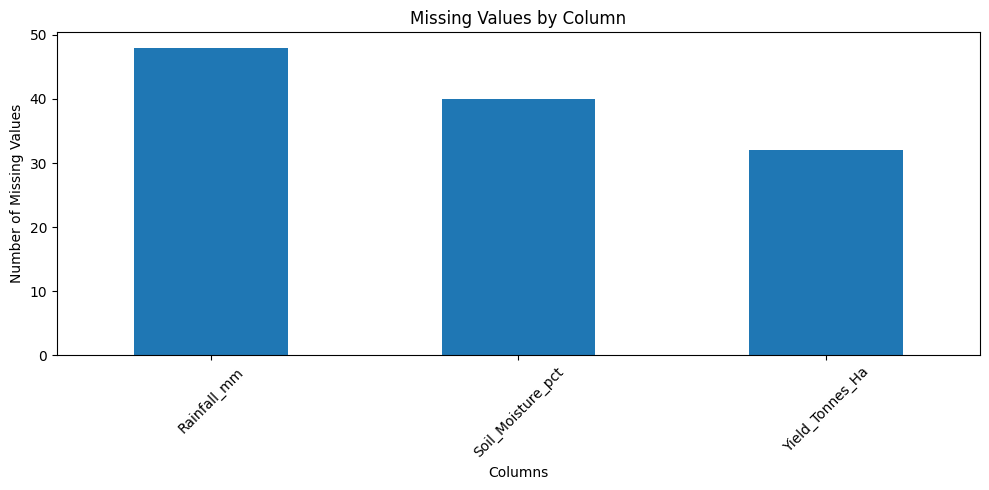

In [16]:
# Visualize missing values in the dataset
missing_values = df.isna().sum()

# Keep only columns that contain missing values
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))
missing_values.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Checking whether any duplicate records exist
print("Number of duplicate rows:", df.duplicated().sum())

# Create a separate copy so that the original dataset remains unchanged
clean_df = df.copy()

Number of duplicate rows: 0


In [18]:
# Columns where missing values need to be filled
columns_with_missing_values = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in columns_with_missing_values:

    # Calculate the median before filling missing values
    median_value = clean_df[column].median()

    # Count missing values before treatment
    missing_before = clean_df[column].isna().sum()

    # Fill missing values with the median
    clean_df[column] = clean_df[column].fillna(median_value)

    # Count missing values after treatment
    missing_after = clean_df[column].isna().sum()

    # Display the result
    print(f"\n--- {column} ---")
    print("Median used for replacement:", median_value)
    print("Missing values before:", missing_before)
    print("Missing values after:", missing_after)


--- Rainfall_mm ---
Median used for replacement: 582.0
Missing values before: 48
Missing values after: 0

--- Soil_Moisture_pct ---
Median used for replacement: 26.4
Missing values before: 40
Missing values after: 0

--- Yield_Tonnes_Ha ---
Median used for replacement: 1.74
Missing values before: 32
Missing values after: 0


In [19]:
# Checking the type of data stored in each column
print("Data types of each columns:")
display(df.dtypes.to_frame("Data Type"))

Data types of each columns:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [20]:
# Check summary statistics for numerical variables
print('Summary statistics for numerical variables (rounded to 2 decimal places):')
display(clean_df.describe().T.round(2))

Summary statistics for numerical variables (rounded to 2 decimal places):


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [21]:
# Checking whether any missing values remain
print("Total missing values after cleaning:",
      clean_df.isna().sum().sum())

# Display the cleaned dataset
display(clean_df.head())

Total missing values after cleaning: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 6. Feature / Variable Review

Task: Explain which variables are most relevant to the seasonal-performance problem and why.

In [22]:
# Numerical and categorical variables
numeric_columns = clean_df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = clean_df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


# Selecting variables that are most relevant to the Seasonal Agriculture Performance Analysis

relevant_variables = {
    "Seasonal Variables": [
        "Season",
        "Crop"
    ],

    "Environmental Variables": [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_pH",
        "Soil_Moisture_pct"
    ],

    "Resource and Farming Variables": [
        "Water_Used_m3",
        "Irrigation_Method",
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Seed_Quality_Score",
        "Nitrogen_kg_ha",
        "Phosphorus_kg_ha",
        "Potassium_kg_ha"
    ],

    "Performance Variables": [
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR"
    ]
}

print("\n\nMost Relevant Variables for Seasonal Performance Analysis:")

for category, variables in relevant_variables.items():
    print(f"\n{category}:")

    for variable in variables:
        print(" -", variable)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


Most Relevant Variables for Seasonal Performance Analysis:

Seasonal Variables:
 - Season
 - Crop

Environmental Variables:
 - Rainfall_mm
 - Avg_Temperature_C
 - Humidity_pct
 - Sunlight_Hours_Day
 - Soil_pH
 - Soil_Moisture_pct

Resource and Farming Variables:
 - Water_Used_m3
 - Irrigation_Method
 - Fertilizer_kg_ha
 - Pesticide_Litre_ha
 - Seed_Quality_Score
 - Nitrogen_kg_ha
 - Phosphorus_kg_ha
 - Potassium_kg_ha

Performance Variables:
 

In [23]:
# Calculate profit margin
clean_df["Profit_Margin_pct"] = np.where(
    clean_df["Revenue_INR"] != 0,
    (clean_df["Profit_INR"] / clean_df["Revenue_INR"]) * 100,
    np.nan
)

# Display the original values along with the calculated profit margin
display(
    clean_df[
        ["Farm_ID", "Revenue_INR", "Profit_INR", "Profit_Margin_pct"]
        ].head(10)
        )

,Farm_ID,Revenue_INR,Profit_INR,Profit_Margin_pct
0,SF10001,30810,-11852,-38.47
1,SF10002,40401,-451950,"-1,118.66"
2,SF10003,190466,-124744,-65.49
3,SF10004,200740,-95704,-47.68
4,SF10005,193607,-144352,-74.56
5,SF10006,269570,-32763,-12.15
6,SF10007,472102,-41239,-8.74
7,SF10008,441265,5065,1.15
8,SF10009,755834,230705,30.52
9,SF10010,2958907,1954835,66.07


In [24]:
# Calculate cost required to produce one tonne
clean_df["Cost_per_Tonne_INR"] = np.where(
    clean_df["Production_Tonnes"] != 0,
    clean_df["Total_Cost_INR"] / clean_df["Production_Tonnes"],
    np.nan
)

# Display the calculated results
display(
    clean_df[ ["Farm_ID", "Production_Tonnes", "Total_Cost_INR", "Cost_per_Tonne_INR"]
                  ].head(10)
                  )

,Farm_ID,Production_Tonnes,Total_Cost_INR,Cost_per_Tonne_INR
0,SF10001,1.30,42662,"32,816.92"
1,SF10002,1.96,492351,"251,199.49"
2,SF10003,2.53,315210,"124,588.93"
3,SF10004,8.28,296444,"35,802.42"
4,SF10005,9.30,337959,"36,339.68"
5,SF10006,3.93,302333,"76,929.52"
6,SF10007,20.57,513341,"24,955.81"
7,SF10008,6.30,436200,"69,238.10"
8,SF10009,10.68,525129,"49,169.38"
9,SF10010,31.35,1004072,"32,027.81"


## 7. Statistical Analysis

In [25]:
# Descriptive statistics
descriptive_stats = clean_df[numeric_columns].describe().T
descriptive_stats["range"] = descriptive_stats["max"] - descriptive_stats["min"]
descriptive_stats["IQR"] = descriptive_stats["75%"] - descriptive_stats["25%"]

descriptive_stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [26]:
season_order = ['Kharif', 'Rabi', 'Zaid']

groups_yield = [clean_df.loc[clean_df["Season"] == s, "Yield_Tonnes_Ha"] for s in season_order]
groups_profit = [clean_df.loc[clean_df["Season"] == s, "Profit_INR"] for s in season_order]

anova_yield = stats.f_oneway(*groups_yield)
anova_profit = stats.f_oneway(*groups_profit)

print("ANOVA — Yield: F =", round(anova_yield.statistic,4), "p =", anova_yield.pvalue)
print("ANOVA — Profit: F =", round(anova_profit.statistic,4), "p =", anova_profit.pvalue)

kw_yield = stats.kruskal(*groups_yield)
kw_profit = stats.kruskal(*groups_profit)

print("\nKruskal-Wallis — Yield:", kw_yield)
print("Kruskal-Wallis — Profit:", kw_profit)
print("\nDecision rule: p < 0.05 indicates evidence of a statistically significant difference among seasons.")

ANOVA — Yield: F = 1.5439 p = 0.21367813841792296
ANOVA — Profit: F = 34.2918 p = 1.7124156677360182e-15

Kruskal-Wallis — Yield: KruskalResult(statistic=np.float64(68.71306722231378), pvalue=np.float64(1.1999054760748268e-15))
Kruskal-Wallis — Profit: KruskalResult(statistic=np.float64(101.92605491126021), pvalue=np.float64(7.362721866797111e-23))

Decision rule: p < 0.05 indicates evidence of a statistically significant difference among seasons.


In [27]:
important_stats = clean_df[
    [
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3",
        "Disease_Pest_Risk_pct",
        "Profit_Margin_pct",
        "Cost_per_Tonne_INR"
    ]
].describe().T

display(important_stats.round(2))

,count,mean,std,min,25%,50%,75%,max
Yield_Tonnes_Ha,"4,000.00",5.24,13.31,0.30,1.05,1.74,2.83,101.44
Production_Tonnes,"4,000.00",43.25,126.88,0.15,5.02,11.77,24.36,"1,424.40"
Revenue_INR,"4,000.00","637,860.05","636,974.71","6,107.00","207,517.25","456,830.50","836,874.75","5,080,900.00"
Total_Cost_INR,"4,000.00","526,303.58","294,419.14","26,826.00","274,577.50","519,082.50","761,996.50","1,349,990.00"
Profit_INR,"4,000.00","111,556.46","545,081.89","-1,019,223.00","-148,731.75","3,673.00","216,187.75","4,345,421.00"
Water_Efficiency_t_per_1000m3,"4,000.00",5.39,8.84,0.14,1.66,2.94,5.15,79.80
Disease_Pest_Risk_pct,"4,000.00",46.37,12.42,5.00,37.30,46.40,54.90,88.90
Profit_Margin_pct,"4,000.00",-45.49,158.09,"-1,461.85",-60.19,1.15,32.89,85.92
Cost_per_Tonne_INR,"4,000.00","55,624.86","54,260.61",568.36,"23,032.64","37,897.60","64,153.10","296,805.13"


In [28]:
statistical_variables = numeric_columns

mean_median = pd.DataFrame({
    "Mean": clean_df[statistical_variables].mean(),
    "Median": clean_df[statistical_variables].median()
})

display(mean_median.round(2))

,Mean,Median
Farm_Area_Hectares,7.89,7.90
Rainfall_mm,600.92,582.00
Avg_Temperature_C,26.82,26.90
Humidity_pct,63.21,63.00
Sunlight_Hours_Day,7.32,7.30
Soil_pH,6.70,6.69
Soil_Moisture_pct,26.51,26.40
Nitrogen_kg_ha,120.25,120.10
Phosphorus_kg_ha,57.78,57.50
Potassium_kg_ha,104.76,105.10


In [29]:
variation = clean_df[
    [
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3",
        "Disease_Pest_Risk_pct"
    ]
].agg(["mean", "std", "min", "max"]).T

display(variation.round(2))

,mean,std,min,max
Yield_Tonnes_Ha,5.24,13.31,0.30,101.44
Production_Tonnes,43.25,126.88,0.15,"1,424.40"
Profit_INR,"111,556.46","545,081.89","-1,019,223.00","4,345,421.00"
Water_Efficiency_t_per_1000m3,5.39,8.84,0.14,79.80
Disease_Pest_Risk_pct,46.37,12.42,5.00,88.90


In [31]:
season_statistics = clean_df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Yield_Std=("Yield_Tonnes_Ha", "std"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Profit_Std=("Profit_INR", "std"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Total_Cost=("Total_Cost_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
)

season_statistics = season_statistics.reindex(
    ["Kharif", "Rabi", "Zaid"]
)

display(season_statistics.round(2))

,Average_Yield,Median_Yield,Yield_Std,Average_Production,Average_Profit,Median_Profit,Profit_Std,Average_Revenue,Average_Total_Cost,Average_Water_Efficiency,Average_Risk
Season,,,,,,,,,,,
Kharif,5.63,1.94,14.39,46.31,"178,914.65","38,808.00","611,549.78","710,719.06","531,804.41",5.89,54.47
Rabi,5.04,1.67,12.75,41.49,"87,689.47","-3,187.00","489,901.25","601,526.05","513,836.58",5.19,40.48
Zaid,4.64,1.46,11.27,38.89,"-24,804.82","-62,144.00","436,356.75","519,171.90","543,976.73",4.41,38.22


In [32]:
financial_statistics = clean_df[
    [
        "Profit_Margin_pct",
        "Cost_per_Tonne_INR"
    ]
].describe().T

display(financial_statistics.round(2))

,count,mean,std,min,25%,50%,75%,max
Profit_Margin_pct,"4,000.00",-45.49,158.09,"-1,461.85",-60.19,1.15,32.89,85.92
Cost_per_Tonne_INR,"4,000.00","55,624.86","54,260.61",568.36,"23,032.64","37,897.60","64,153.10","296,805.13"


## 8. Univariate Analysis

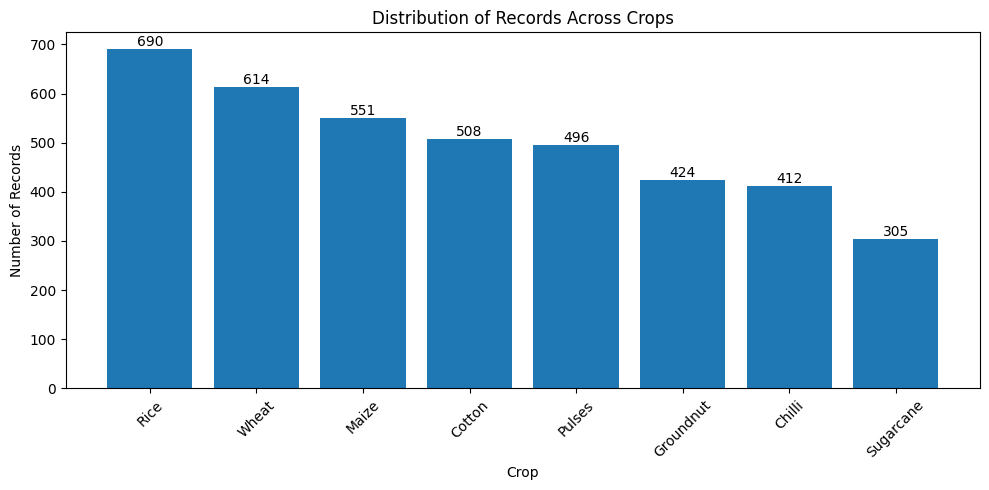

In [33]:
# Categorical Variable – Crop Distribution
crop_counts = clean_df["Crop"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(crop_counts.index, crop_counts.values)

plt.title("Distribution of Records Across Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

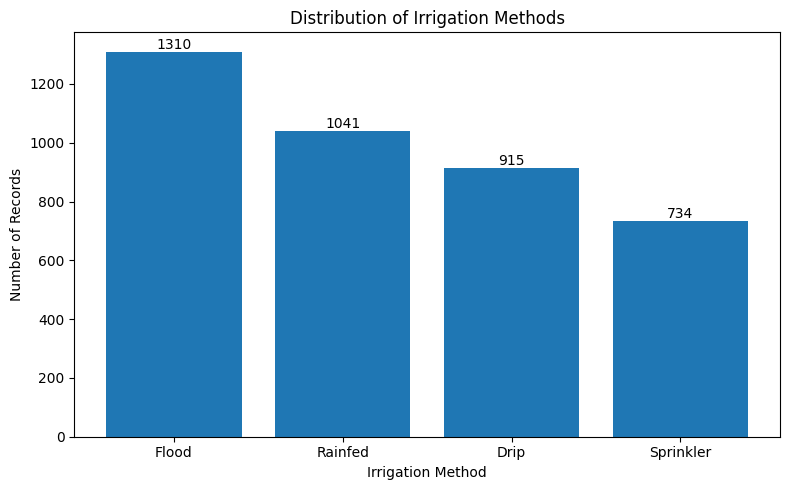

In [34]:
# Categorical Variable – Irrigation Method
irrigation_counts = clean_df["Irrigation_Method"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(irrigation_counts.index, irrigation_counts.values)

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

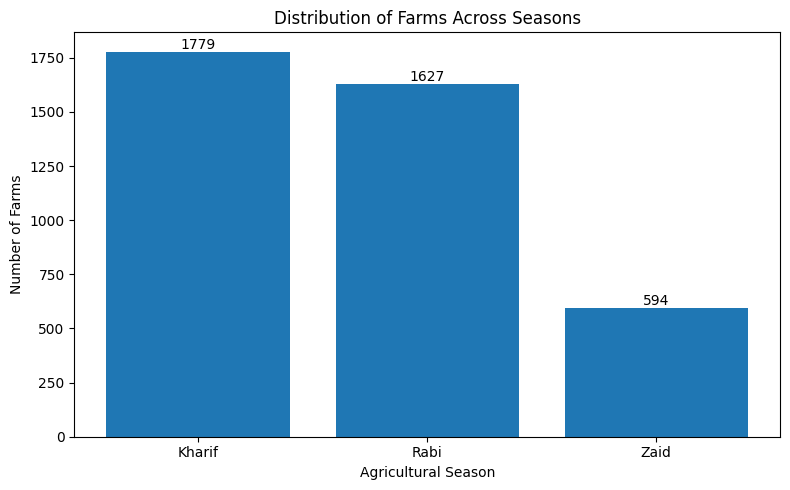

In [35]:
# Seasonal Distribution
season_counts = (
    clean_df["Season"]
    .value_counts()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(8, 5))
bars = plt.bar(season_counts.index, season_counts.values)

plt.title("Distribution of Farms Across Seasons")
plt.xlabel("Agricultural Season")
plt.ylabel("Number of Farms")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

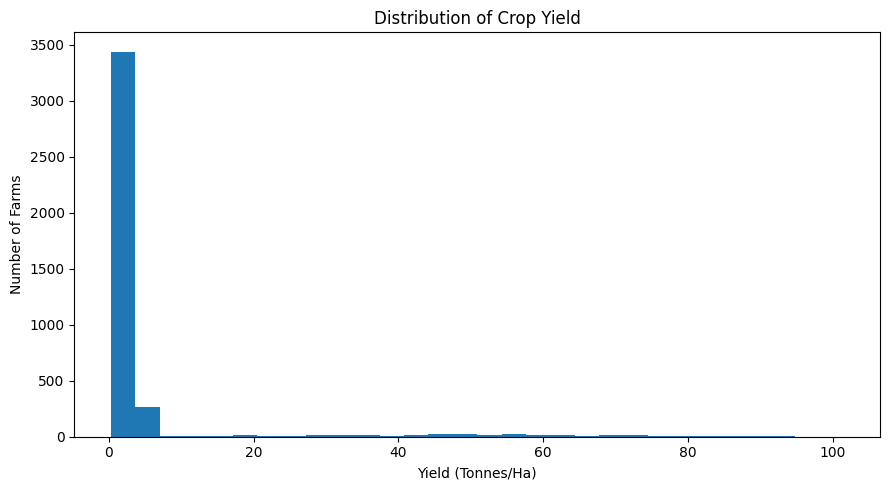

In [36]:
# Numerical Variable – Yield Distribution
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Yield_Tonnes_Ha"],
    bins=30
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

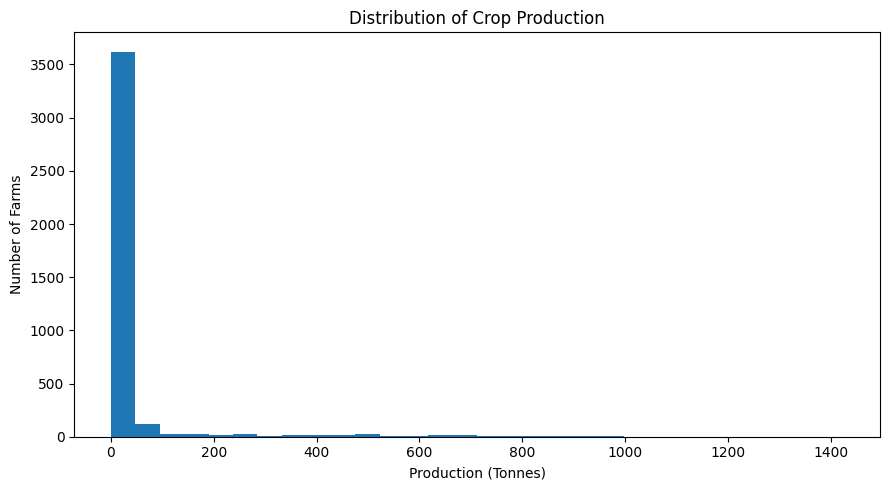

In [37]:
# Numerical Variable – Production Distribution
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Production_Tonnes"],
    bins=30
)

plt.title("Distribution of Crop Production")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

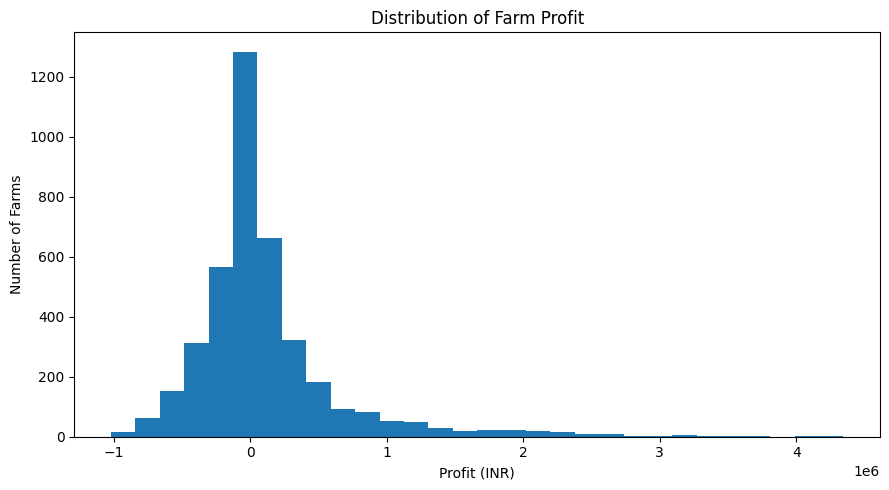

In [38]:
# Economic Variable – Profit Distribution
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Profit_INR"],
    bins=30
)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

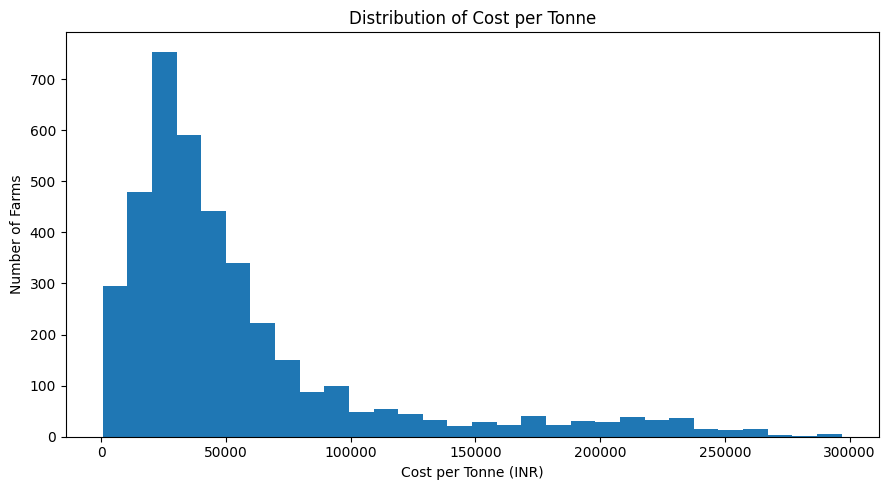

In [39]:
# Economic Variable – Cost per Tonne
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Cost_per_Tonne_INR"],
    bins=30
)

plt.title("Distribution of Cost per Tonne")
plt.xlabel("Cost per Tonne (INR)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

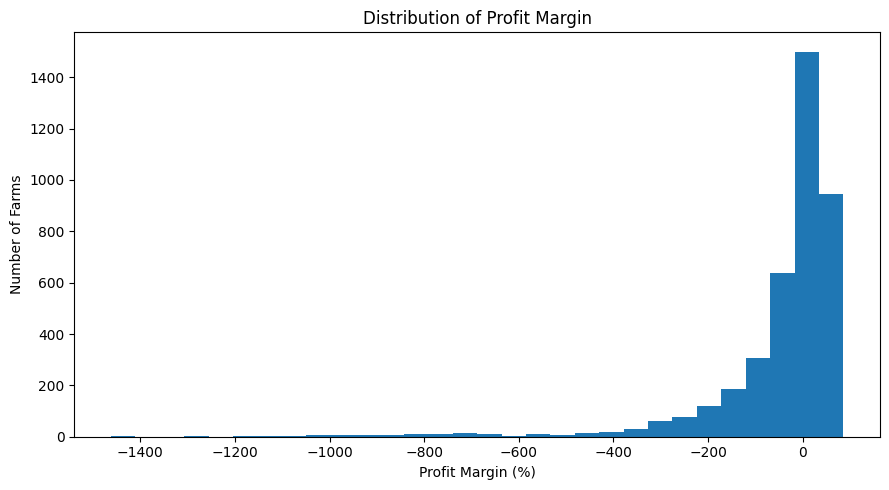

In [40]:
# Economic Variable – Profit Margin
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Profit_Margin_pct"],
    bins=30
)

plt.title("Distribution of Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

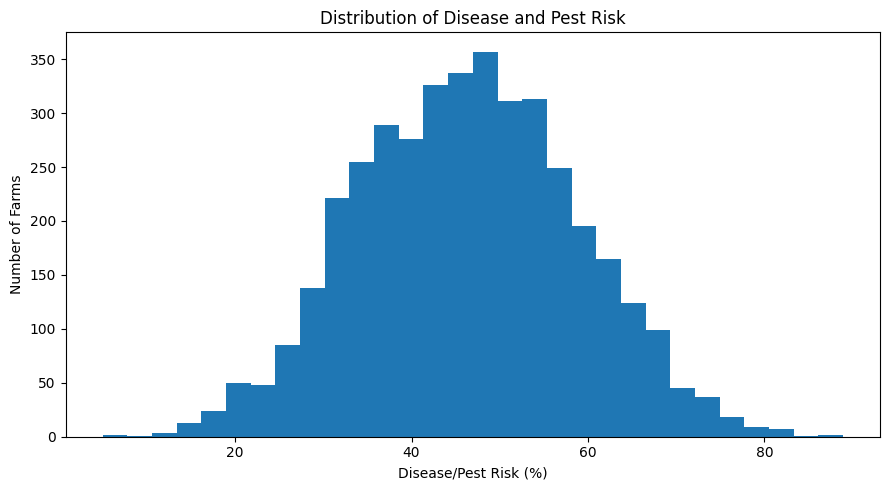

In [42]:
# Disease/Pest Risk
plt.figure(figsize=(9, 5))

plt.hist(
    clean_df["Disease_Pest_Risk_pct"],
    bins=30
)

plt.title("Distribution of Disease and Pest Risk")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

## 9. Outlier Analysis
Investigate potential outliers using statistical and visual methods.

In [43]:
# Identify Outliers Using IQR
# Select important numerical variables
outlier_variables = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Cost_per_Tonne_INR",
    "Profit_Margin_pct"
]

# Find outliers using the IQR method
for column in outlier_variables:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[column] < lower_limit) |
        (clean_df[column] > upper_limit)
    ]

    print(f"\n{column}")
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))


Yield_Tonnes_Ha
Lower limit: -1.62
Upper limit: 5.5
Number of outliers: 302

Production_Tonnes
Lower limit: -23.98
Upper limit: 53.36
Number of outliers: 333

Profit_INR
Lower limit: -696111.0
Upper limit: 763567.0
Number of outliers: 404

Cost_per_Tonne_INR
Lower limit: -38648.04
Upper limit: 125833.78
Number of outliers: 405

Profit_Margin_pct
Lower limit: -199.81
Upper limit: 172.5
Number of outliers: 362


In [44]:
outlier_summary = []

for column in outlier_variables:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = (
        (clean_df[column] < lower_limit) |
        (clean_df[column] > upper_limit)
    ).sum()

    outlier_summary.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_limit,
        upper_limit,
        outlier_count
    ])

outlier_summary_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Lower Limit",
        "Upper Limit",
        "Outlier Count"
    ]
)

display(outlier_summary_df.round(2))

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,Yield_Tonnes_Ha,1.05,2.83,1.78,-1.62,5.50,302
1,Production_Tonnes,5.02,24.36,19.34,-23.98,53.36,333
2,Profit_INR,"-148,731.75","216,187.75","364,919.50","-696,111.00","763,567.00",404
3,Cost_per_Tonne_INR,"23,032.64","64,153.10","41,120.45","-38,648.04","125,833.78",405
4,Profit_Margin_pct,-60.19,32.89,93.08,-199.81,172.50,362


### 9.1. Visual Outlier Detection – Box Plot

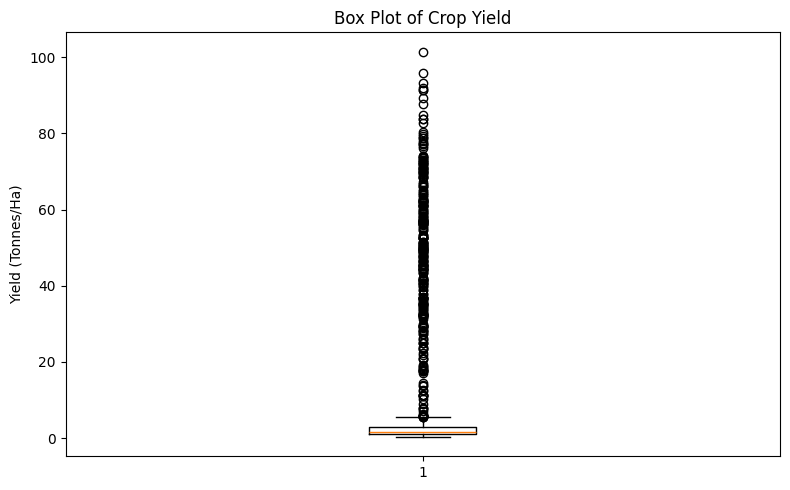

In [45]:
# Yield
plt.figure(figsize=(8, 5))

plt.boxplot(clean_df["Yield_Tonnes_Ha"].dropna())

plt.title("Box Plot of Crop Yield")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

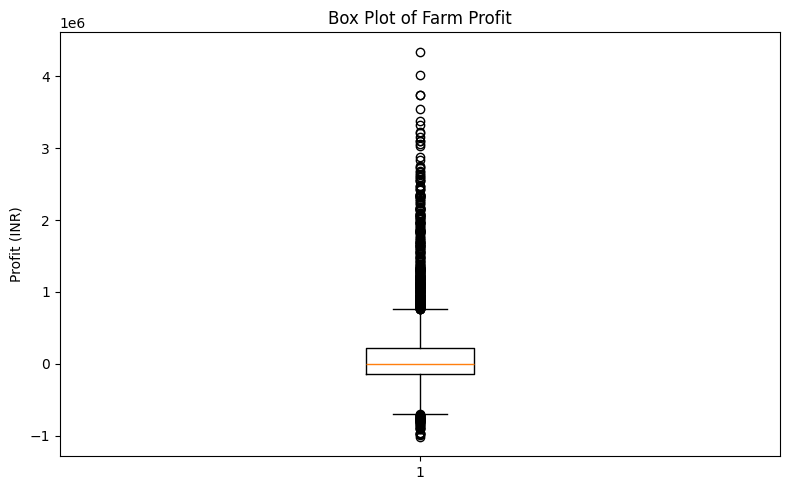

In [46]:
# Profit
plt.figure(figsize=(8, 5))

plt.boxplot(clean_df["Profit_INR"].dropna())

plt.title("Box Plot of Farm Profit")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

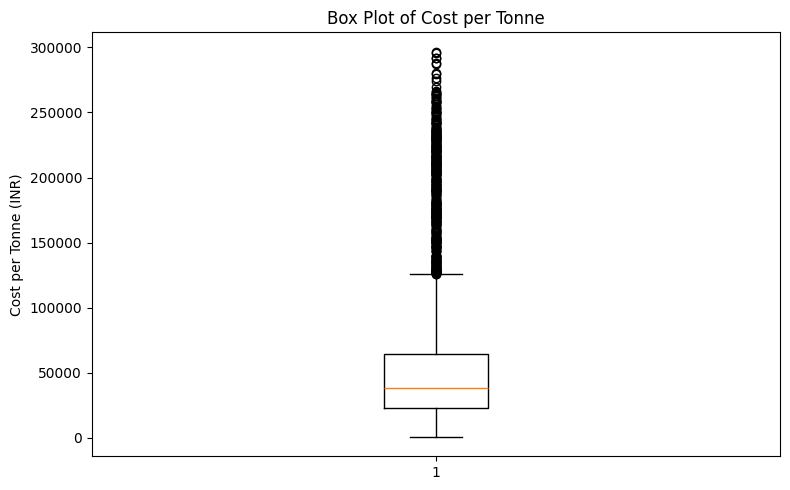

In [47]:
# Cost Per Tone
plt.figure(figsize=(8, 5))

plt.boxplot(clean_df["Cost_per_Tonne_INR"].dropna())

plt.title("Box Plot of Cost per Tonne")
plt.ylabel("Cost per Tonne (INR)")

plt.tight_layout()
plt.show()

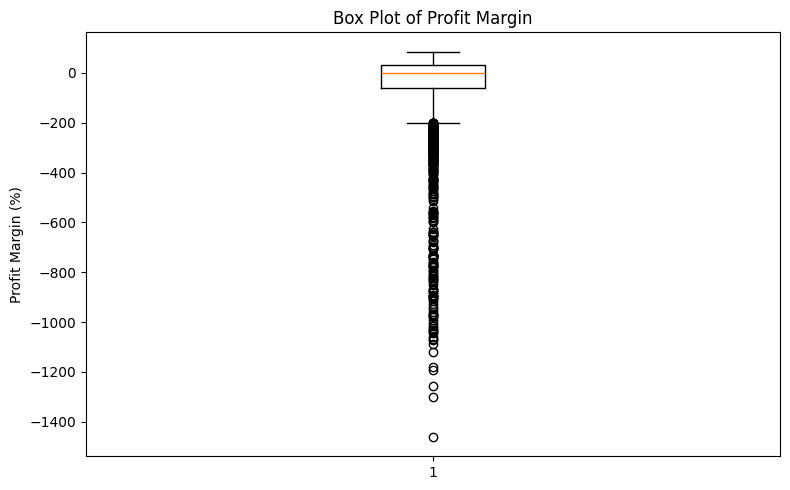

In [48]:
# Profit Mergin
plt.figure(figsize=(8, 5))

plt.boxplot(clean_df["Profit_Margin_pct"].dropna())

plt.title("Box Plot of Profit Margin")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

## 10. Bivariate Analysis
Bivariate analysis examines relationships or differences between two variables.

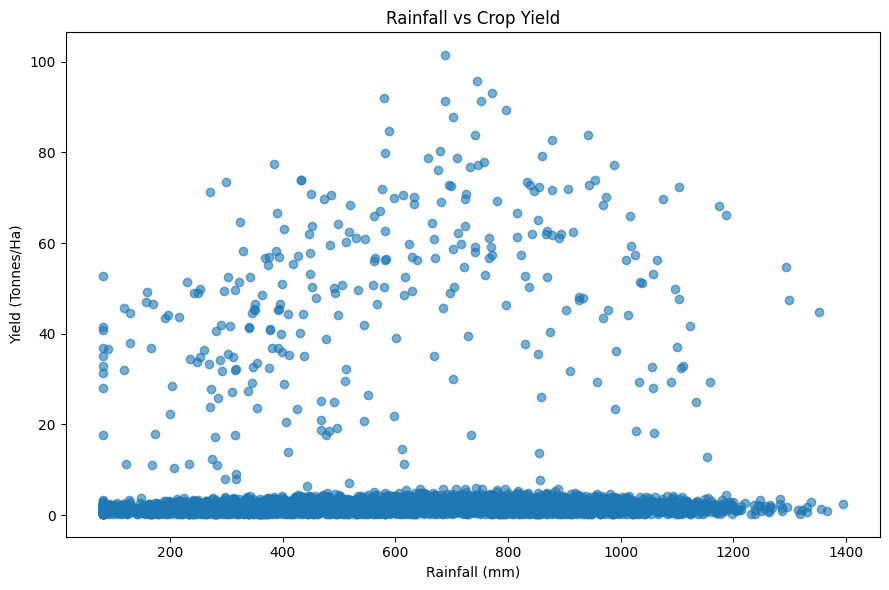

In [49]:
# Rainfall vs Crop Yield
# Question: Does rainfall have a relationship with crop yield?
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Rainfall_mm"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

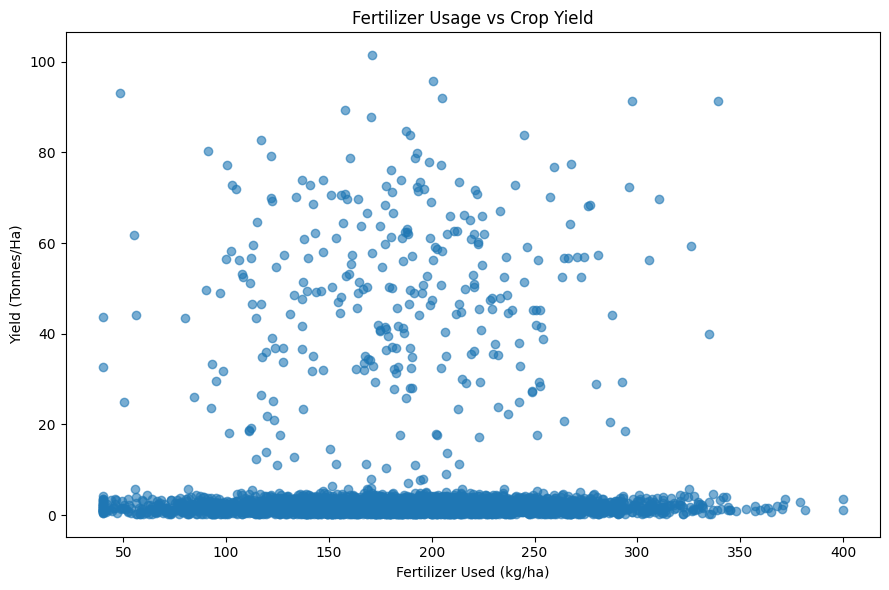

In [50]:
# Fertilizer Usage vs Crop Yield
# Question: Does fertilizer usage have a relationship with crop yield?
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Fertilizer_kg_ha"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer Used (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

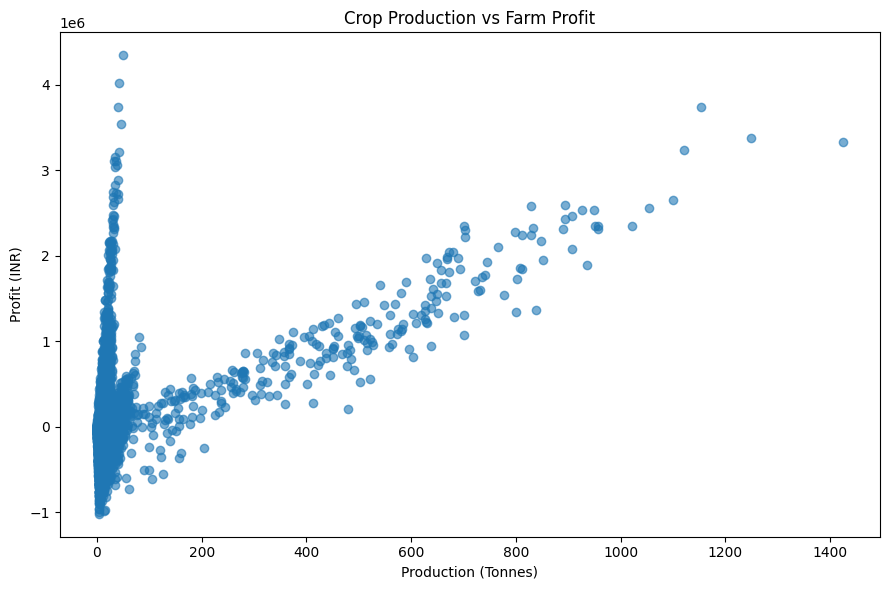

In [51]:
# Production vs Profit
#Question: Does higher crop production lead to higher profit?
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Production_Tonnes"],
    clean_df["Profit_INR"],
    alpha=0.6
)

plt.title("Crop Production vs Farm Profit")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

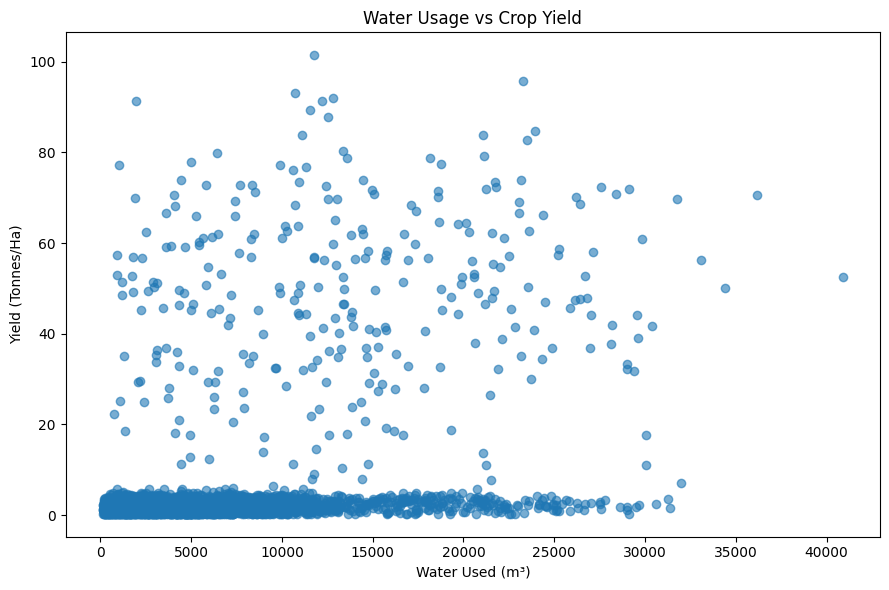

In [52]:
# Water Usage vs Yield
#Question: Does using more water result in higher crop yield?
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Water_Used_m3"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

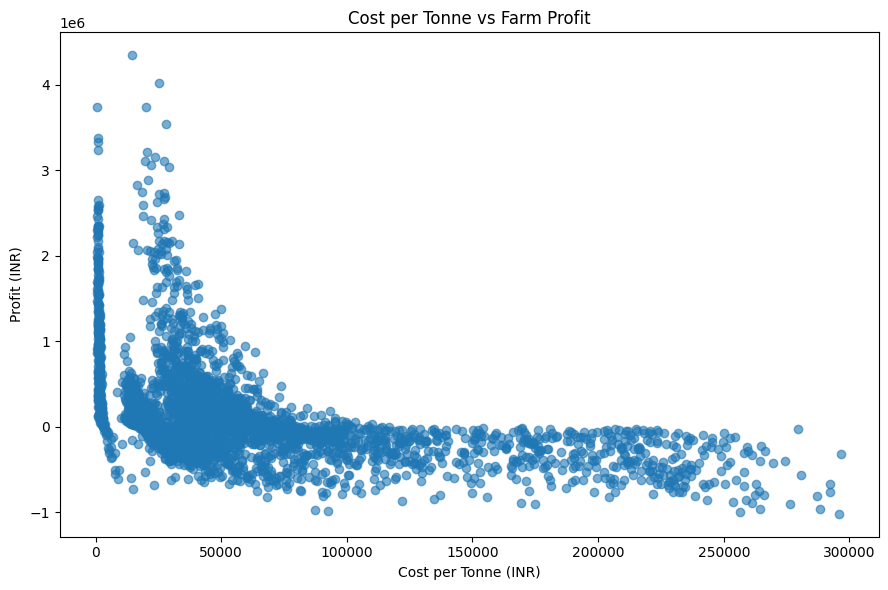

In [53]:
# Cost per Tonne vs Profit
#Question: How does production cost efficiency relate to farm profit?
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Cost_per_Tonne_INR"],
    clean_df["Profit_INR"],
    alpha=0.6
)

plt.title("Cost per Tonne vs Farm Profit")
plt.xlabel("Cost per Tonne (INR)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

## 11. Multivariate Analysis
**Objective:**

Multivariate analysis is used to study the relationship between more than two variables simultaneously. In this project, it helps understand how agricultural performance changes with season, crop, state, environmental conditions, resource usage, and economic outcomes.

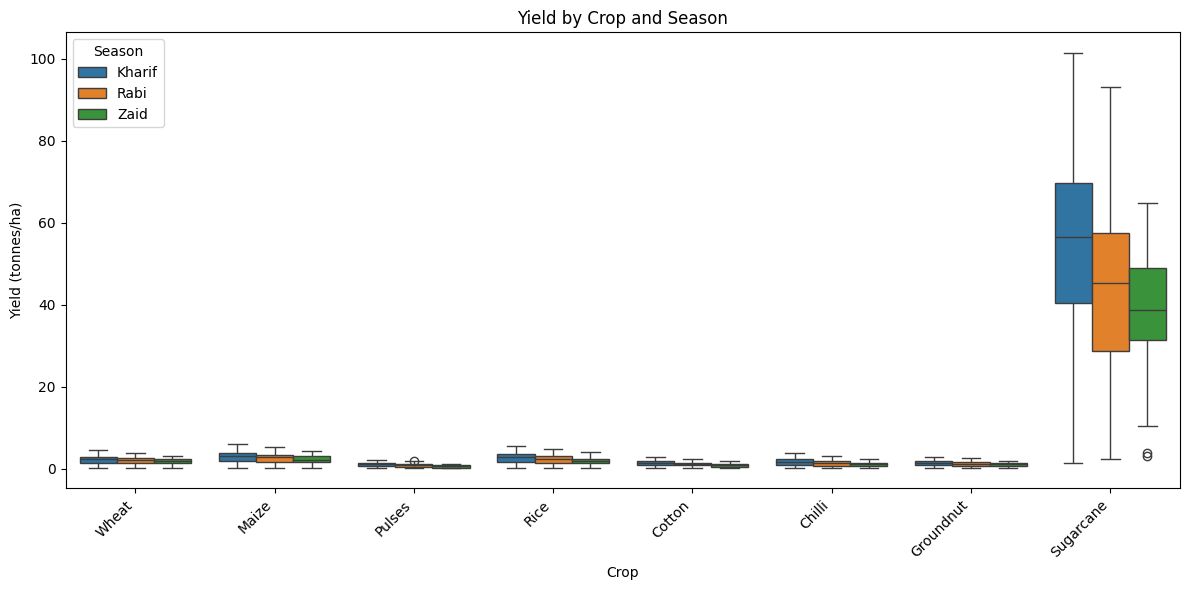

In [54]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

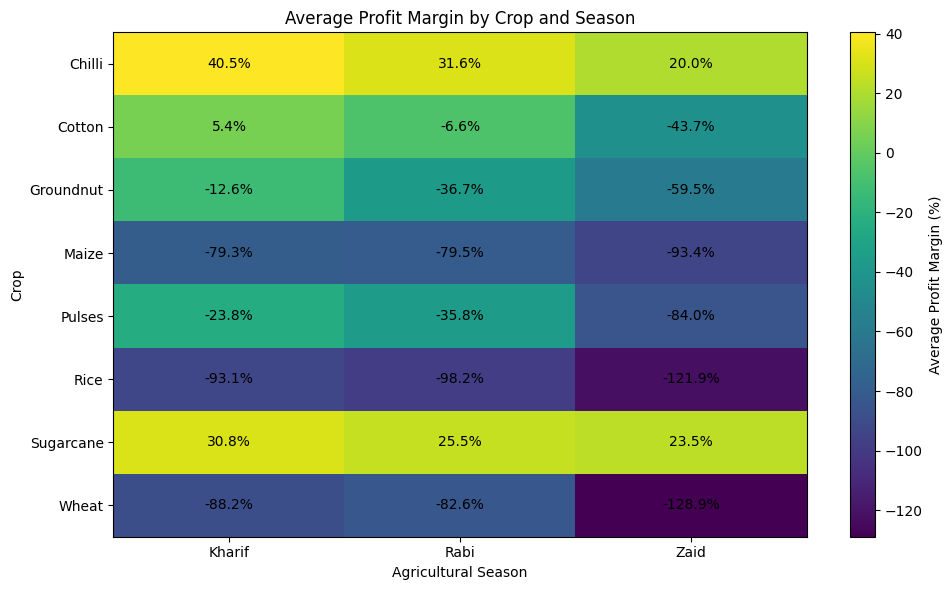

In [55]:
# Crop × Season × Profit Margin — Heatmap
#Question: Which crop-season combinations provide better profitability?
crop_season_margin = (
    clean_df
    .pivot_table(
        index="Crop",
        columns="Season",
        values="Profit_Margin_pct",
        aggfunc="mean"
    )
    .reindex(columns=["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(10, 6))

plt.imshow(
    crop_season_margin,
    aspect="auto"
)

plt.xticks(
    range(len(crop_season_margin.columns)),
    crop_season_margin.columns
)

plt.yticks(
    range(len(crop_season_margin.index)),
    crop_season_margin.index
)

plt.title("Average Profit Margin by Crop and Season")
plt.xlabel("Agricultural Season")
plt.ylabel("Crop")

for i in range(len(crop_season_margin.index)):
    for j in range(len(crop_season_margin.columns)):

        value = crop_season_margin.iloc[i, j]

        if not pd.isna(value):
            plt.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center"
            )

plt.colorbar(label="Average Profit Margin (%)")

plt.tight_layout()
plt.show()

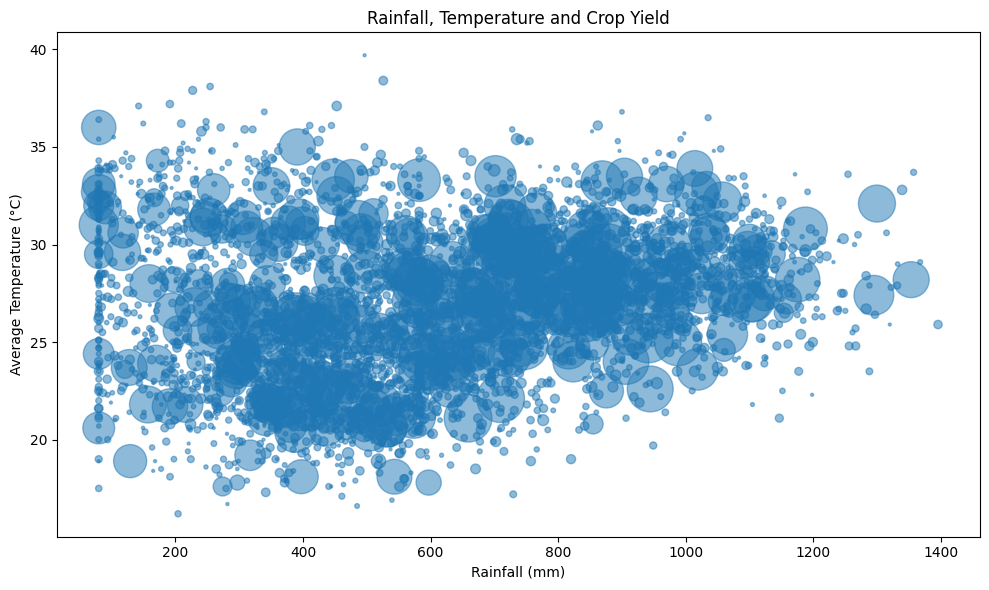

In [56]:
#Rainfall × Temperature × Yield — Bubble Scatter Plot
#Question: How do rainfall and temperature together relate to crop yield?
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    clean_df["Rainfall_mm"],
    clean_df["Avg_Temperature_C"],
    s=clean_df["Yield_Tonnes_Ha"] * 15,
    alpha=0.5
)

plt.title("Rainfall, Temperature and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Average Temperature (°C)")

plt.tight_layout()
plt.show()

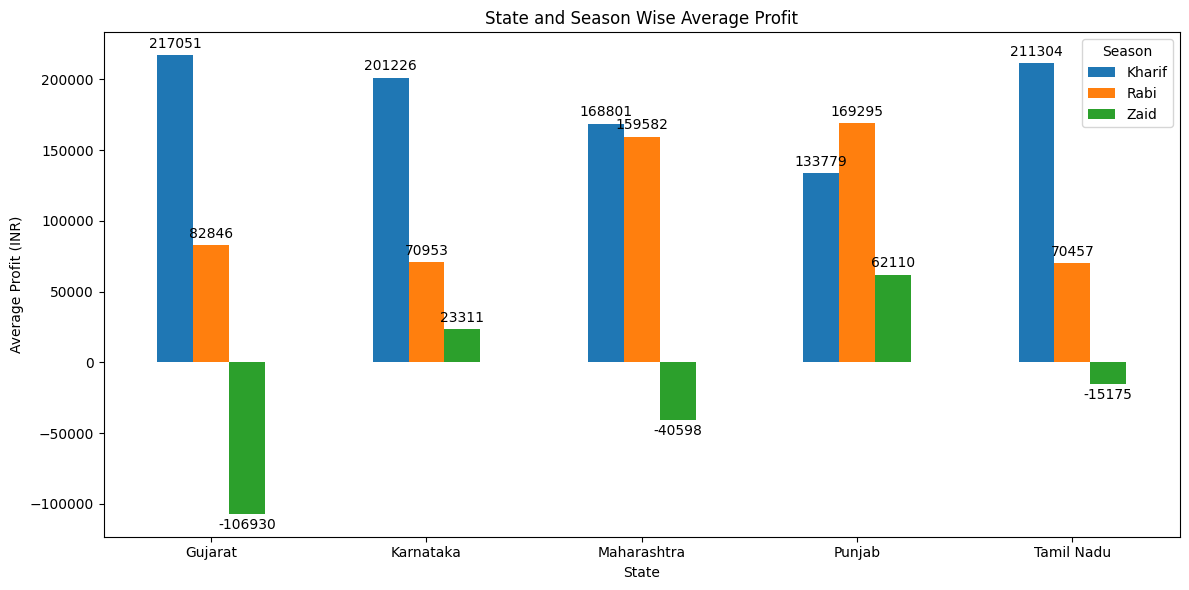

In [57]:
# Season × State × Profit — Grouped Bar Chart
#Question: How does profitability vary across states and seasons?
top_5_states = (
    clean_df.groupby("State")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

state_season_profit = (
    clean_df[clean_df["State"].isin(top_5_states)]
    .groupby(["State", "Season"])["Profit_INR"]
    .mean()
    .unstack()
)

state_season_profit = state_season_profit[
    ["Kharif", "Rabi", "Zaid"]
]

ax = state_season_profit.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("State and Season Wise Average Profit")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.legend(title="Season")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()
plt.show()

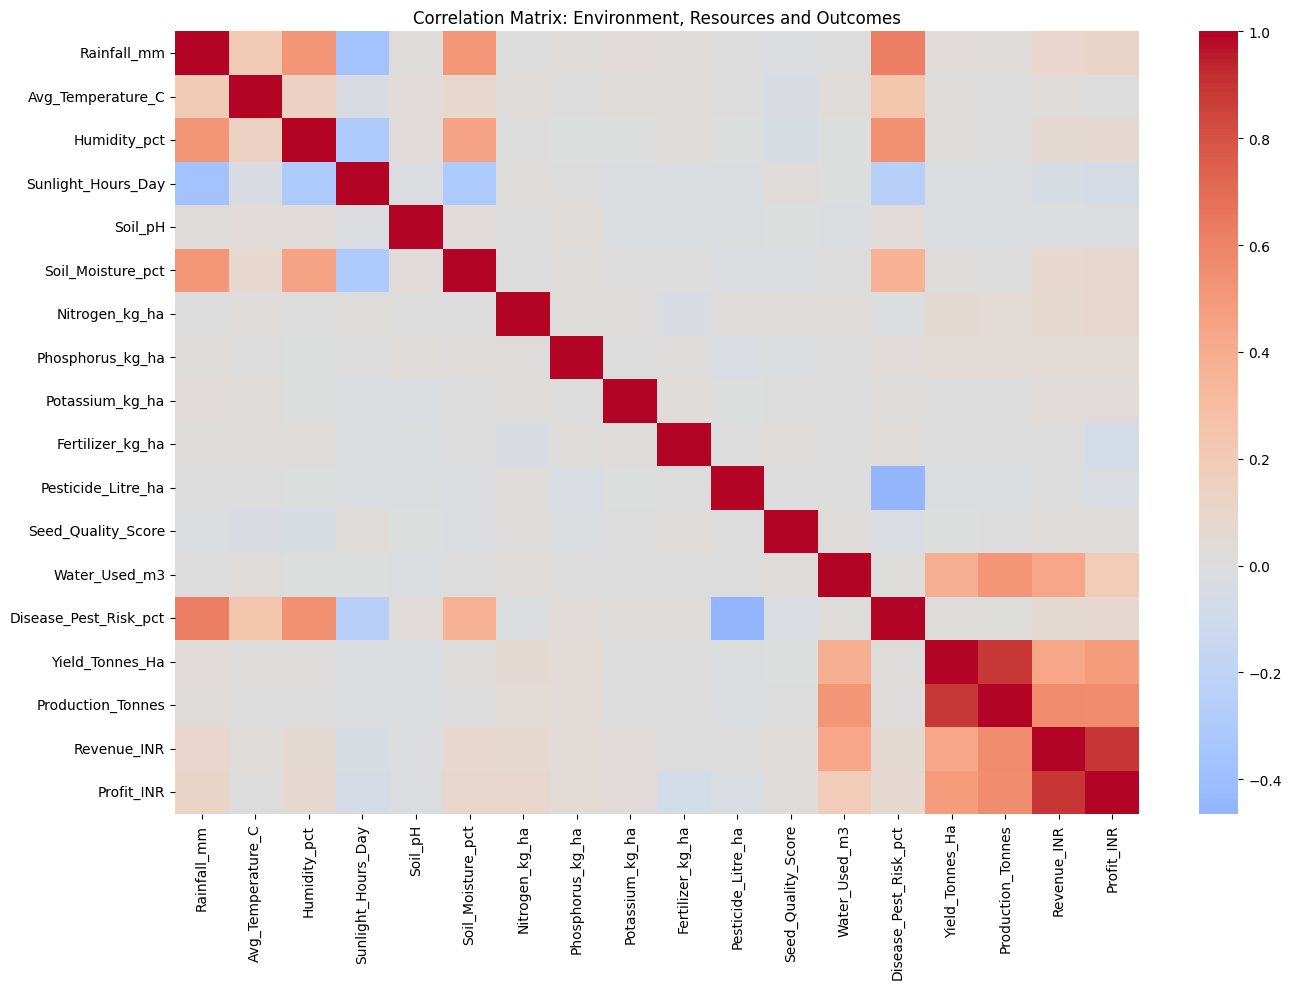

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Water_Used_m3,0.39,0.52,0.43,0.19
Nitrogen_kg_ha,0.05,0.05,0.08,0.09
Phosphorus_kg_ha,0.05,0.04,0.04,0.05
Rainfall_mm,0.03,0.02,0.10,0.11
Disease_Pest_Risk_pct,0.01,0.01,0.06,0.07
Humidity_pct,0.01,0.00,0.06,0.06
Soil_Moisture_pct,0.01,0.01,0.08,0.09
Avg_Temperature_C,0.01,0.01,0.03,0.01
Potassium_kg_ha,0.00,0.00,0.03,0.03
Fertilizer_kg_ha,0.00,0.00,0.01,-0.07


In [58]:
# Correlation Matrix of Environmental Factors, Resources and Agricultural Outcomes
env_cols = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day",
             "Soil_pH","Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha",
             "Potassium_kg_ha","Fertilizer_kg_ha","Pesticide_Litre_ha",
             "Seed_Quality_Score","Water_Used_m3","Disease_Pest_Risk_pct"]
outcome_cols = ["Yield_Tonnes_Ha","Production_Tonnes","Revenue_INR","Profit_INR"]

corr = clean_df[env_cols + outcome_cols].corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Environment, Resources and Outcomes")
plt.tight_layout()
plt.show()

display(corr[outcome_cols].loc[env_cols].sort_values("Yield_Tonnes_Ha", ascending=False).round(3))

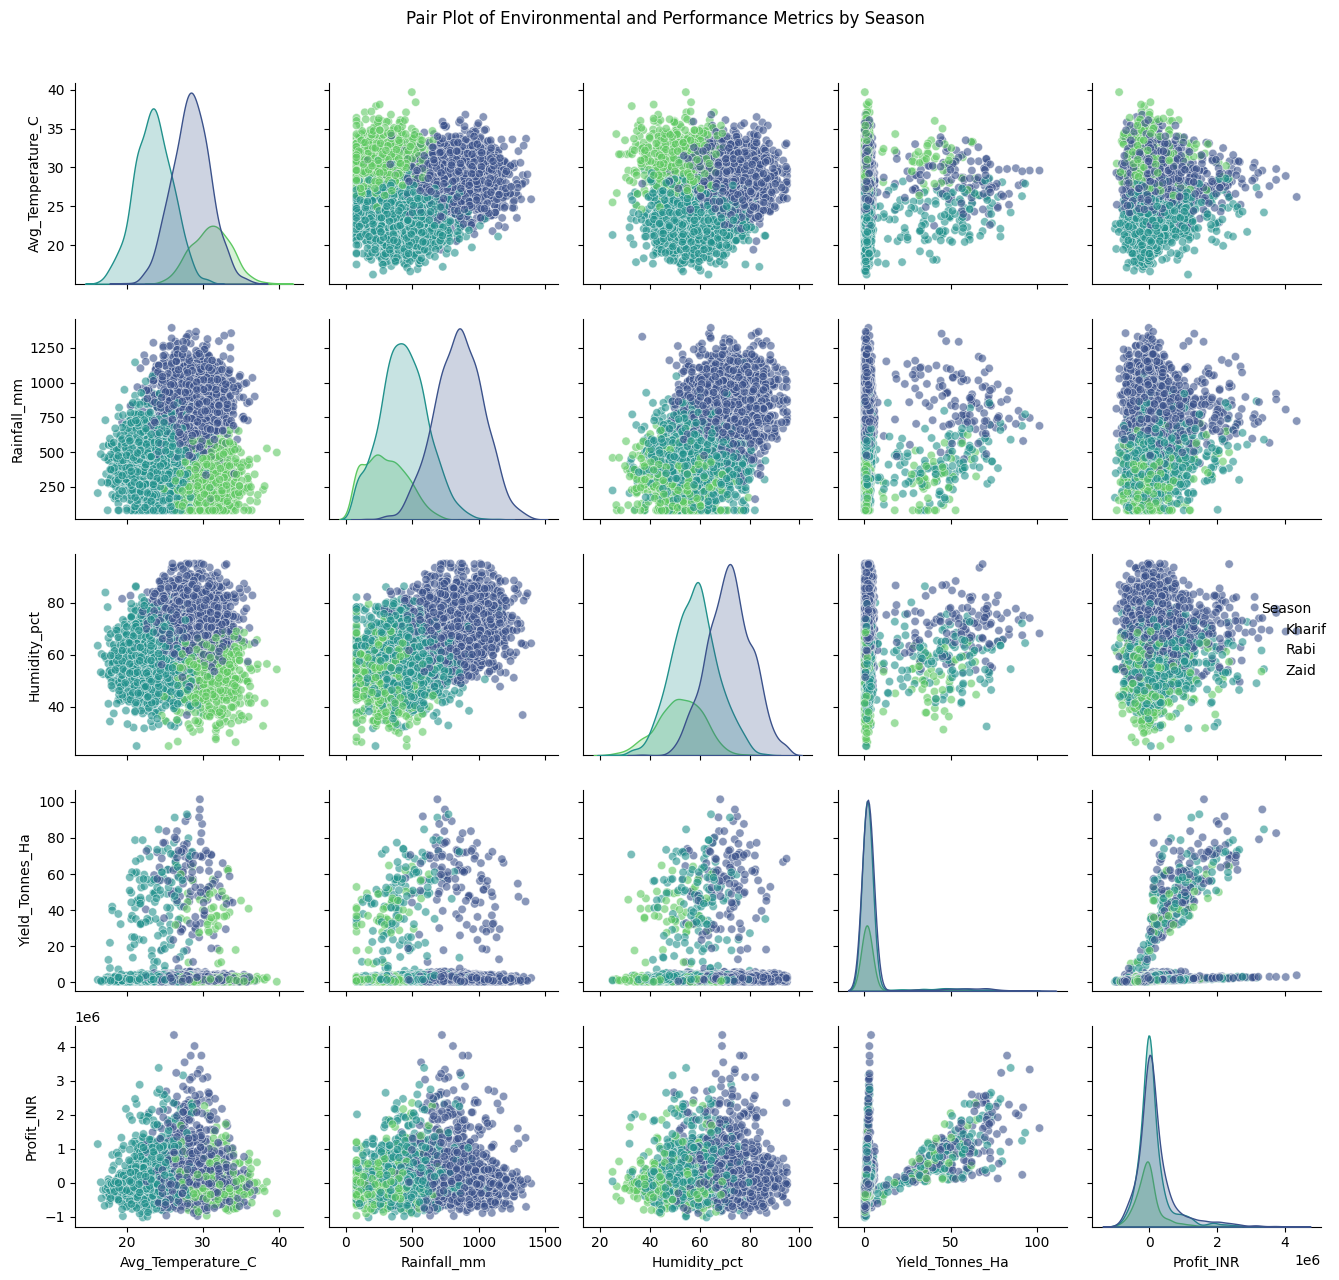

In [59]:
# Pair Plot of Key Environmental and Performance Metrics by Season
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

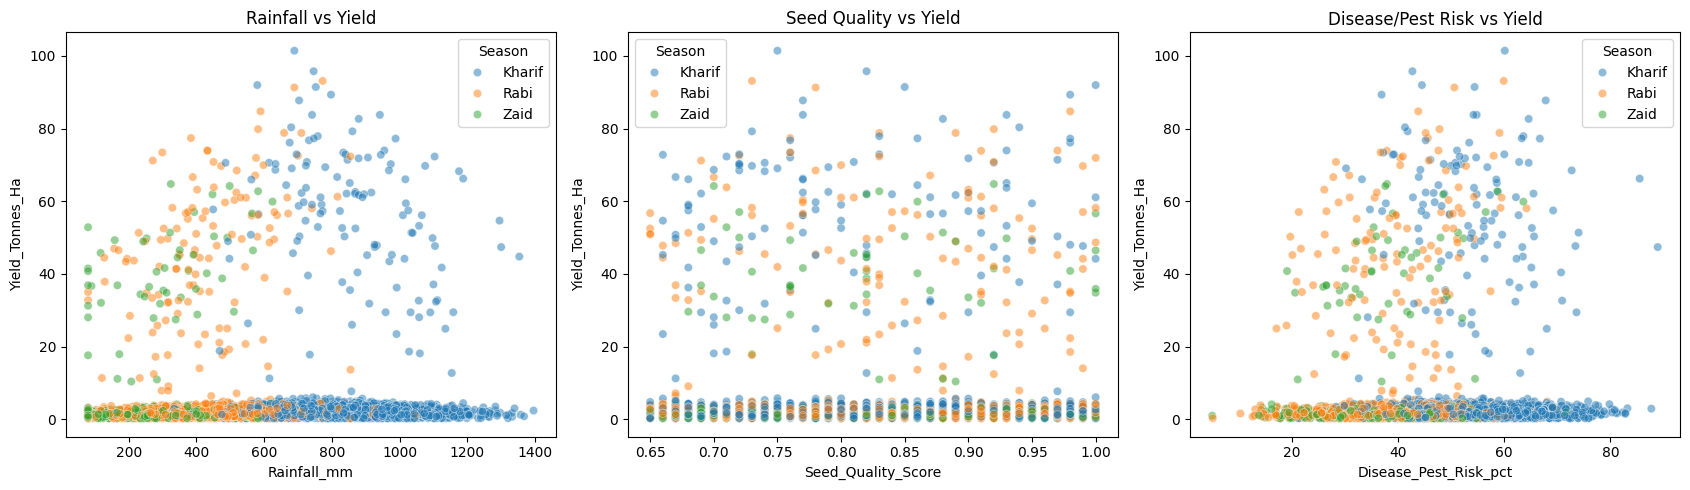

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.scatterplot(data=clean_df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5, ax=axes[0])
axes[0].set_title("Rainfall vs Yield")
sns.scatterplot(data=clean_df, x="Seed_Quality_Score", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5, ax=axes[1])
axes[1].set_title("Seed Quality vs Yield")
sns.scatterplot(data=clean_df, x="Disease_Pest_Risk_pct", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5, ax=axes[2])
axes[2].set_title("Disease/Pest Risk vs Yield")
plt.tight_layout()
plt.show()

## 12. Seasonal Comparison
### 12.1. Agricultural Performance

In [61]:
season_performance = season_statistics[
    [
        "Average_Yield",
        "Average_Production",
        "Average_Water_Efficiency"
    ]
]

season_performance.columns = [
    "Average Yield (t/ha)",
    "Average Production (t)",
    "Water Efficiency (t/1000 m³)"
]

display(season_performance.round(2))

,Average Yield (t/ha),Average Production (t),Water Efficiency (t/1000 m³)
Season,,,
Kharif,5.63,46.31,5.89
Rabi,5.04,41.49,5.19
Zaid,4.64,38.89,4.41


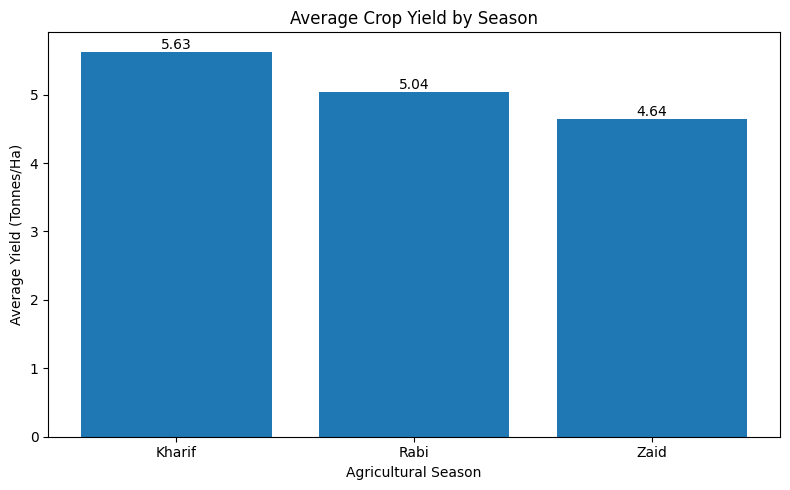

In [62]:
# Compare average crop yield across seasons
plt.figure(figsize=(8, 5))

yield_values = season_statistics["Average_Yield"]

bars = plt.bar(
    yield_values.index,
    yield_values.values
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Agricultural Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 12.2. Economic Performance

In [63]:
# Compare the economic performance of each season
season_economic = season_statistics[
    [
        "Average_Revenue",
        "Average_Total_Cost",
        "Average_Profit"
    ]
]

season_economic.columns = [
    "Average Revenue (INR)",
    "Average Cost (INR)",
    "Average Profit (INR)"
]

display(season_economic.round(0))

,Average Revenue (INR),Average Cost (INR),Average Profit (INR)
Season,,,
Kharif,"710,719.00","531,804.00","178,915.00"
Rabi,"601,526.00","513,837.00","87,689.00"
Zaid,"519,172.00","543,977.00","-24,805.00"


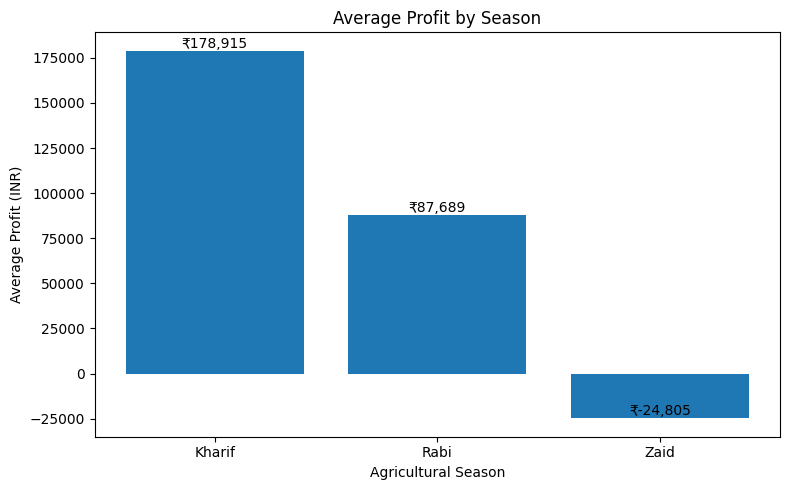

In [65]:
# Compare average profit across seasons
plt.figure(figsize=(8, 5))
profit_values = season_economic["Average Profit (INR)"]

bars = plt.bar(
    profit_values.index,
    profit_values.values
)

plt.title("Average Profit by Season")
plt.xlabel("Agricultural Season")
plt.ylabel("Average Profit (INR)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [66]:
# Compare environmental conditions and agricultural risk
# Calculate seasonal averages for environmental factors
seasonal_env_agg = clean_df.groupby("Season").agg(
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean")
).reindex(season_order) # Ensure order is consistent

# Combine with Average_Risk from season_statistics
season_environment = seasonal_env_agg.copy()
season_environment["Average_Risk"] = season_statistics["Average_Risk"]

season_environment.columns = [
    "Average Rainfall (mm)",
    "Average Temperature (°C)",
    "Average Disease/Pest Risk (%)"
]

display(season_environment.round(2))

,Average Rainfall (mm),Average Temperature (°C),Average Disease/Pest Risk (%)
Season,,,
Kharif,849.20,28.45,54.47
Rabi,437.62,23.49,40.48
Zaid,304.65,31.04,38.22


## 13. Additional Analysis

### 13.1. Analysis 1: Does water usage affect crop yield?
    - Question: Does water usage affect crop yield?
    - Analysis: Examined the relationship between Water_Used_m3 and Yield_Tonnes_Ha.
    - Visualization: Scatter plot.
    - Interpretation: Helps understand whether increased water usage is associated with higher crop productivity.

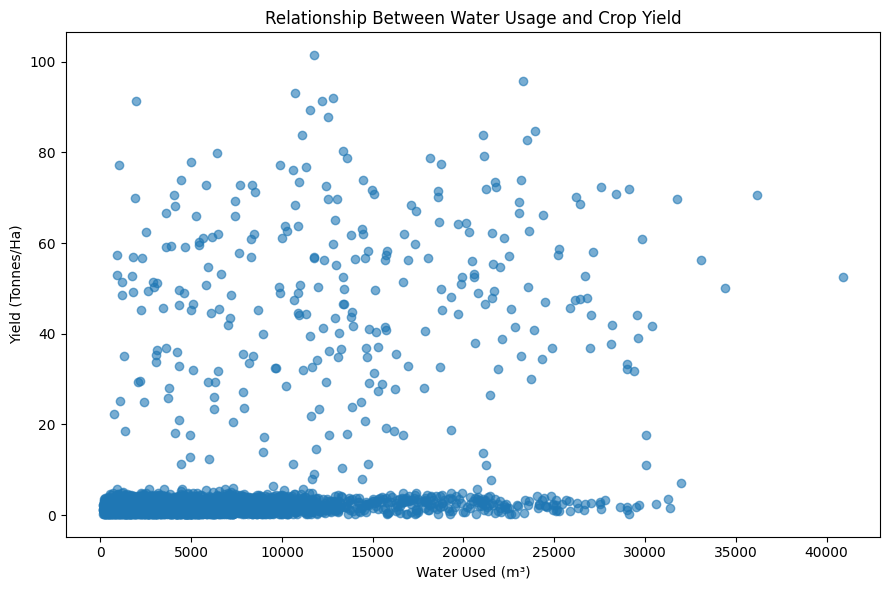

In [67]:
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Water_Used_m3"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.6
)

plt.title("Relationship Between Water Usage and Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

### 13.2. Analysis 2: Does fertilizer usage affect farm profit?
    - Question: Does fertilizer usage affect farm profit?
    - Analysis: Examined the relationship between Fertilizer_kg_ha and Profit_INR.
    - Visualization: Scatter plot.
    - Interpretation: Helps understand the economic impact of fertilizer usage.

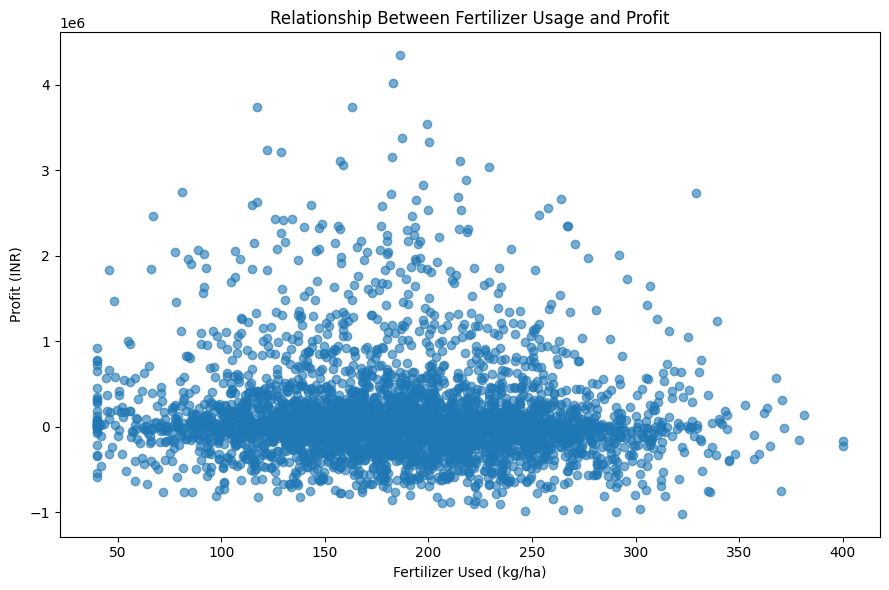

In [68]:
plt.figure(figsize=(9, 6))

plt.scatter(
    clean_df["Fertilizer_kg_ha"],
    clean_df["Profit_INR"],
    alpha=0.6
)

plt.title("Relationship Between Fertilizer Usage and Profit")
plt.xlabel("Fertilizer Used (kg/ha)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

### 13.3. Analysis 3: Which season has the highest disease and pest risk?
    - Question: Which season has the highest disease and pest risk?
    - Analysis: Calculated average Disease_Pest_Risk_pct for Kharif, Rabi and Zaid.
    - Visualization: Bar graph.
    - Interpretation: Identifies the season with comparatively higher agricultural risk.

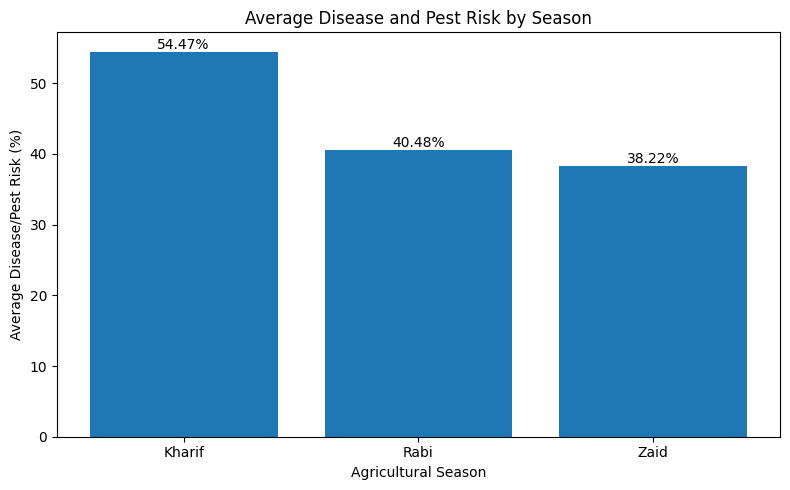

In [69]:
season_risk = (
    clean_df
    .groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .reindex(["Kharif", "Rabi", "Zaid"])
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    season_risk.index,
    season_risk.values
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Agricultural Season")
plt.ylabel("Average Disease/Pest Risk (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 14. Key Findings

In [70]:
print("\nKey Findings")
print("-" * 50)
best_yield_season = season_statistics["Average_Yield"].idxmax()
best_profit_season = season_statistics["Average_Profit"].idxmax()
best_water_season = season_statistics["Average_Water_Efficiency"].idxmax()
highest_risk_season = season_statistics["Average_Risk"].idxmax()

print(f"1. Highest average yield: {best_yield_season} ({season_statistics.loc[best_yield_season,'Average_Yield']:.2f} t/ha).")
print(f"2. Highest average profit: {best_profit_season} (INR {season_statistics.loc[best_profit_season,'Average_Profit']:,.0f}).")
print(f"3. Highest average water efficiency: {best_water_season} ({season_statistics.loc[best_water_season,'Average_Water_Efficiency']:.2f} t/1,000 m³).")
print(f"4. Highest average disease/pest risk: {highest_risk_season} ({season_statistics.loc[highest_risk_season,'Average_Risk']:.2f}%).")

print("\nAverage yield by crop:")
display(clean_df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False).to_frame("Average_Yield_T_ha").round(2))

print("\nSeasonal economic indicators:")
display(season_statistics[["Average_Revenue","Average_Total_Cost","Average_Profit"]].round(0))


Key Findings
--------------------------------------------------
1. Highest average yield: Kharif (5.63 t/ha).
2. Highest average profit: Kharif (INR 178,915).
3. Highest average water efficiency: Kharif (5.89 t/1,000 m³).
4. Highest average disease/pest risk: Kharif (54.47%).

Average yield by crop:


,Average_Yield_T_ha
Crop,
Sugarcane,46.64
Maize,2.71
Rice,2.43
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92



Seasonal economic indicators:


,Average_Revenue,Average_Total_Cost,Average_Profit
Season,,,
Kharif,"710,719.00","531,804.00","178,915.00"
Rabi,"601,526.00","513,837.00","87,689.00"
Zaid,"519,172.00","543,977.00","-24,805.00"


## 15. Conclusions and Data-Driven Recommendations

The analysis suggests that agricultural planning should consider season, crop, productivity, profitability, water efficiency, environmental conditions and production costs together rather than relying on a single performance measure. Kharif shows the strongest overall performance in the dataset, while Zaid requires closer investigation because of its lower yield, lower water efficiency and negative average profit. However, the findings represent associations within this dataset and should be validated with additional farm-level information before making major operational or policy decisions.

### Conclusions
- Agricultural performance differs across Kharif, Rabi and Zaid in this dataset.
- Kharif shows the strongest average yield, profit and water-efficiency profile.
- Zaid has the weakest average economic outcome and lower water efficiency.
- Crop type is a major source of variation; sugarcane has much higher tonnes/ha than the other crops, so overall yield should be interpreted with crop mix in mind.
- Environmental conditions, inputs, irrigation, seed quality and disease/pest risk should be evaluated together.
- Statistical tests help determine whether observed seasonal differences are unlikely to be due to random sampling variation.
- Extreme observations should be investigated in agricultural context rather than removed blindly.

### Recommendations
1. **Season-specific planning:** tailor inputs and resource allocation to each season.
2. **Improve Zaid economics:** investigate high costs, lower yield and water-efficiency constraints before increasing resource use.
3. **Use efficient irrigation:** compare irrigation methods using both yield and water efficiency.
4. **Make crop-specific decisions:** compare profitability and resource requirements by crop because yield scales differ substantially.
5. **Manage disease/pest risk:** prioritize monitoring and preventive measures in higher-risk seasons/regions.
6. **Monitor environmental conditions:** use rainfall, temperature and soil moisture as supporting variables for seasonal planning.
7. **Future predictive model:** build a regression or machine-learning model for yield/profit prediction using season, crop, environment, inputs and irrigation.

**Important:** These recommendations are based on the supplied dataset and should be validated with field-level agricultural knowledge before operational decisions.

## 16. Final Project Checklist

- [x] Initial Data Understanding and Exploration
- [x] Data Quality Assessment and Cleaning (Missing Values, Duplicates)
- [x] Seasonal Performance Analysis (Yield, Profit, Water Efficiency)
- [x] Crop-wise Performance Analysis
- [x] Regional Performance Analysis (State, District)
- [x] Environmental Factor Impact Analysis (Rainfall, Temp, Humidity, Soil)
- [x] Resource Usage Analysis (Water, Fertilizer, Pesticide)
- [x] Statistical Analysis (ANOVA, Kruskal-Wallis, Descriptive Stats)
- [x] Outlier Analysis and Interpretation (IQR method, Box Plots)
- [x] Identification of Key Findings and Insights
- [x] Formulation of Conclusions and Data-Driven Recommendations
- [x] Comprehensive Data Visualization